<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Solutions to Exercise Set 1, Exercise 0 -  Tensors and Gradients
In this notebook you will learn to let PyTorch compute a derivative.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

## Tensors
In the context of machine learning, a **tensor** is a scalar, a vector, a matrix or a higher-dimensional array.

In [2]:
 # Example 1 - 1D tensor
a = torch.tensor([1, 2, 3, 4])
print(a)

tensor([1, 2, 3, 4])


Recall the **scalar product** (German: Skalarprodukt), also called dot product of two vectors, say $a$, $b$ both of length $n$. 
$$\langle a, b \rangle = a_1 b_1+a_2 b_2 +\cdots+ a_n b_n$$

In [3]:
torch.dot(a, a) # 1*1 + 2*2 + 3*3 + 4*4 = 30

tensor(30)

In [4]:
# Example 2 - 3D tensor
x = torch.tensor(np.arange(24).reshape(2, 3, 4))
x

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

The first dimension will later often play the role of a *batch dimension*. In a **batch** multiple examples are processed together allowing for efficient parallel computations on a GPU.  
E.g. here `x` could be interpreted as 2 images of size $3\times 4$ pixels each.   
The **elements** of a tensor are numbers, typically floating point numbers with 64 bit (full/**double** precision), 32 bit (**float**) or 16 bit (half) precision or integers (*int*).  



In [5]:
x[0,1,3] # 7

tensor(7)

In [6]:
x.dim() # number of dimensions (sometimes called 'rank')

3

In [7]:
x.shape # returns the sizes of the dimensions

torch.Size([2, 3, 4])

Many common linear algebra operations are available in PyTorch and named similarly as in Numpy or TensorFlow, for example matrix multiplication.

In [8]:
# a matrix of floating point numbers with double precision
theta = torch.tensor([[2,1],[3,2],[4,3],[5,4]], dtype=torch.float64) 
print (theta.shape)
print (theta)

torch.Size([4, 2])
tensor([[2., 1.],
        [3., 2.],
        [4., 3.],
        [5., 4.]], dtype=torch.float64)


In [9]:
x = x.to(torch.float64) # convert integers to float for type compatibility
y = torch.matmul(x, theta) 
# A matrix multiplication is executed, treating every x[i] as a matrix and multiplying it by theta
# This way, a whole 'batch' of matrix multiplications is executed

print (y.shape)
print (y)
for i in range(2): # verify that this is indeed repeated matrix multiplication
    print (f"{i}-th entry equal:", y[i].equal(torch.matmul(x[i], theta)))

torch.Size([2, 3, 2])
tensor([[[ 26.,  20.],
         [ 82.,  60.],
         [138., 100.]],

        [[194., 140.],
         [250., 180.],
         [306., 220.]]], dtype=torch.float64)
0-th entry equal: True
1-th entry equal: True


## Automatic Differentiation

Consider the following function in two variables 
$$ y = f(x,a) = x^2 - a\cdot x.$$

This particular function is very simple and the derivative can be computed easily with paper and pencil. However, PyTorch can compute derivatives on complex and fairly general python functions (including ```if``` conditions, loops, etc.). 

We will later use this in a context where
 - $f$ is a neural network
 - $x$ is an image (a photo)
 - $a$ are the parameters of the neural network.
 
Indeed, it is useful in different contexts to compute the derivative of the neural network's output with respect to parameters $a$ as well as with respect to the input image $x$.

In [10]:
def f(x, a):
    return x**2 - a * x

x_ = 2. # a specific value for x 
a_ = 2. # a specific value for a
y_ = f(x_, a_) # the output value

Let's first make a plot where we see the values of $y$ near the specific point $(x,a) = (2,2)$:

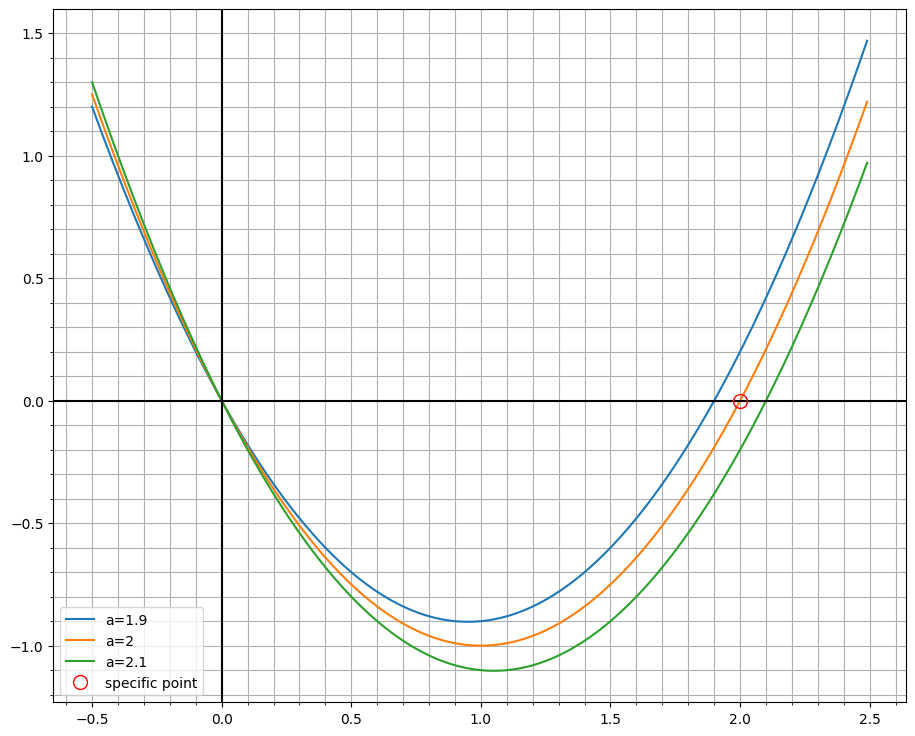

In [11]:
fig, ax = plt.subplots(figsize = (11, 9))
x_range = np.arange(-.5, 2.5, 0.01)

for a in [1.9, 2, 2.1]:
    ax.plot(x_range, f(x_range, a), label = "a="+str(a))
ax.axhline(0, color = "black")
ax.axvline(0, color = "black")
ax.plot(x_, y_, 'ro', markersize = 10, fillstyle = 'none', label = 'specific point')
ax.minorticks_on()
ax.grid(which = 'both')
ax.legend();

## Compute the gradient with respect to $x$ and with respect to $a$
in the <span style="color:red">point</span> $(x, a) = (2, 2)$. More particular, make PyTorch compute

$$ \frac{\partial f}{\partial x} (2, 2) \qquad \text{ and } \qquad \frac{\partial f}{\partial a} (2, 2).$$
**Tip:** [torch.autograd](https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html)

In [12]:
# Create PyTorch tensors with gradients enabled
x = torch.tensor(x_, dtype=torch.float64, requires_grad=True)
a = torch.tensor(a_, dtype=torch.float64, requires_grad=True)

# Compute the output
y = f(x, a)

# Compute gradients with respect to all inputs by a single backward call
y.backward()

# Extract gradients
dy_dx = x.grad.item()
dy_da = a.grad.item()

print("dy/dx =", dy_dx)
print("dy/da =", dy_da)

dy/dx = 2.0
dy/da = -2.0


**Solution:**
```
dy/dx =  2.0
dy/da =  -2.0
```

## Analytical solution

$$\begin{align*}
\frac{\partial f}{\partial x} (x, a) &= 2\cdot x - a &&\Rightarrow & \frac{\partial f}{\partial x} (2, 2) &= 2 \\
\frac{\partial y}{\partial a} (x, a) &= -x           &&\Rightarrow & \frac{\partial f}{\partial a} (2, 2) &= -2
\end{align*}
$$

The solution can also approximately be measured from the plot:

<img src="../dy_dx.png" width="200px"/>

## Gradient of a composition of functions
Let $\bf x:= (x_0,x_1,x_2)$ be a vector ('input') and ${\theta}:= (\theta_0,\theta_1,\theta_2)$ be another vector ('parameters').
Define 
$$L:= \left(\langle \theta, {\bf x}\rangle -10 \right)^2 = \left(\theta_0 x_0 + \theta_1 x_1 + \theta_2 x_2 -10\right)^2.$$

<img src="../grad_graph.png" width="600px"/>

Compute 
$\frac{\partial L }{\partial \theta_0}(x, \theta)$ for
$\theta=(1,2,3)$ and ${\bf x} = (2,3,4)$.

Define the function `get_L` which computes $L$ with above formula from $\bf x $ and $\theta$.  
Tip: Use [torch.dot](https://pytorch.org/docs/stable/generated/torch.dot.html)

In [13]:
def get_L(x, theta):
    # YOUR CODE HERE, 1-3 lines
    A = torch.dot(x, theta)
    B = A - 10
    L = B**2
    return L

In [14]:
# define x and theta as torch tensors and initialize them with the given values
x = torch.tensor([2, 3, 4], dtype=torch.float32)
theta = torch.tensor([1, 2, 3], dtype=torch.float32,
                     requires_grad=True) # tell PyTorch to track gradients for theta

In [15]:
L = get_L(x, theta) # the output value, a scalar tensor
print (L)

tensor(100., grad_fn=<PowBackward0>)


In [16]:
# If we use a Pytorch tensor, but do not want to track gradients, we can use the detach method
# This is required when we want to convert the tensor to a numpy array
L_value = L.detach().numpy()
print(L_value)

100.0


Solution:
```
100.0
```

Compute the partial derivatives of $L$ with respect to $\theta$ using `backward`.

In [17]:
# YOUR CODE HERE, 2 lines
L.backward()
g = theta.grad

# print the first element of the gradient
print (g[0])

tensor(40.)


You can check your results by hand using the [chain rule](https://en.wikipedia.org/wiki/Chain_rule), which you may remember from high school or another calculus class (German: Analysis):

$$\frac{\partial L }{\partial \theta_0}(x, \theta)= 2 \cdot B \cdot x_0,$$
where $B= \theta_0 x_0 + \theta_1 x_1 + \theta_2 x_2 -10$.